# Titanic Survival Prediction 🚢

**Goal:** Predict whether a passenger survived the Titanic disaster, based on their data (age, sex, class, fare, etc.).

This is a **binary classification** problem. In this notebook I go through a complete machine learning workflow:
1. Load & explore the data
2. Exploratory Data Analysis (EDA) with visualizations
3. Data cleaning (handle missing values, encode text, drop useless columns)
4. Train & compare 3 models (KNN, Decision Tree, SVM)
5. Evaluate the best model & draw conclusions

**Dataset:** Titanic dataset (891 passengers) — the classic ML starter dataset.

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 4)

## 2. Load & Explore the Data
First step with any real dataset: look at it before doing anything.

In [2]:
df = pd.read_csv("Titanic-Dataset.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
# dataset structure & data types
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [4]:
# check for missing values per column
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

**Observations:**
- `Age` has ~177 missing values
- `Cabin` is mostly empty (~77% missing) → not usable
- `Embarked` has only 2 missing
- Columns like `Name`, `Ticket`, `PassengerId` are unique identifiers → no predictive value

## 3. Exploratory Data Analysis (EDA)
Who survived? Let's find the patterns visually before modeling.

/tmp/ipykernel_577/2035137587.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Survived', ax=axes[0], palette='Set2')
/tmp/ipykernel_577/2035137587.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(['Died', 'Survived'])


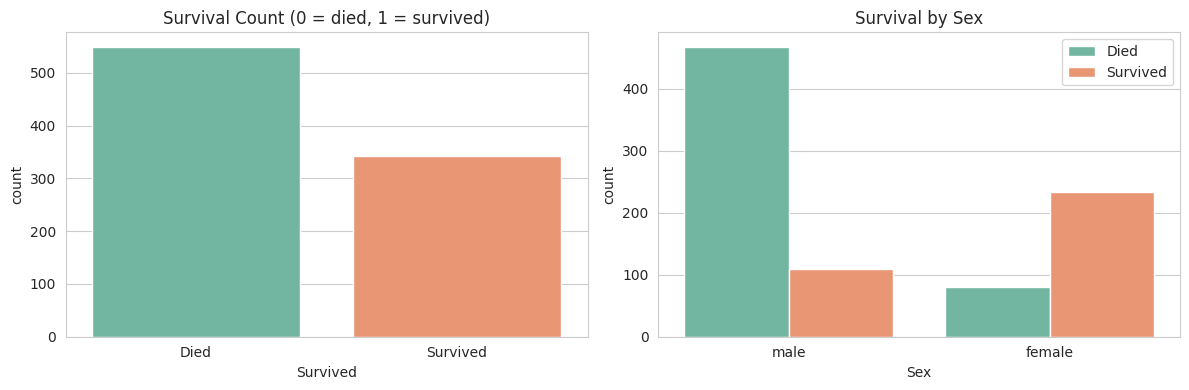

In [5]:
# survival rate overall
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.countplot(data=df, x='Survived', ax=axes[0], palette='Set2')
axes[0].set_title('Survival Count (0 = died, 1 = survived)')
axes[0].set_xticklabels(['Died', 'Survived'])

sns.countplot(data=df, x='Sex', hue='Survived', ax=axes[1], palette='Set2')
axes[1].set_title('Survival by Sex')
axes[1].legend(['Died', 'Survived'])
plt.tight_layout()
plt.show()

**Insight:** Females had a much higher survival rate than males — the 'women and children first' policy is clearly visible in the data.

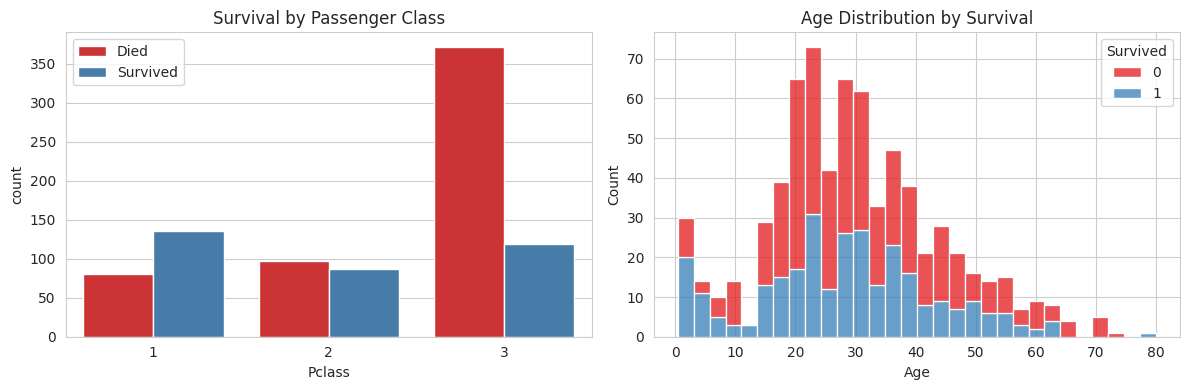

In [6]:
# survival by passenger class & age distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.countplot(data=df, x='Pclass', hue='Survived', ax=axes[0], palette='Set1')
axes[0].set_title('Survival by Passenger Class')
axes[0].legend(['Died', 'Survived'])

sns.histplot(data=df, x='Age', hue='Survived', bins=30, ax=axes[1], palette='Set1', multiple='stack')
axes[1].set_title('Age Distribution by Survival')
plt.tight_layout()
plt.show()

**Insights:**
- 1st class passengers survived at a much higher rate than 3rd class → wealth/location on the ship mattered.
- Young children show a relatively higher survival rate.

## 4. Data Cleaning
Real data is messy. Before modeling I need to:
- **Fill missing values** (`Age` with median, `Embarked` with most common)
- **Drop** the `Cabin` column (too many missing)
- **Encode text into numbers** (`Sex`, `Embarked`) — models only understand numbers
- **Drop useless columns** (`Name`, `Ticket`, `PassengerId`)

In [7]:
# 1. handle missing values
df = df.drop(columns=['Cabin'])                                  # too many missing
df['Age'] = df['Age'].fillna(df['Age'].median())                # numeric -> median
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0]) # text -> most common

# 2. encode text into numbers
df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})
df['Embarked'] = df['Embarked'].map({'S': 0, 'C': 1, 'Q': 2})

# 3. drop columns with no predictive value
df = df.drop(columns=['Name', 'Ticket', 'PassengerId'])

# verify: no missing values & all numeric now
print("Missing values left:", df.isnull().sum().sum())
df.head()

Missing values left: 0


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,0,22.0,1,0,7.2500,0
1,1,1,1,38.0,1,0,71.2833,1
2,1,3,1,26.0,0,0,7.9250,0
3,1,1,1,35.0,1,0,53.1000,0
4,0,3,0,35.0,0,0,8.0500,0


## 5. Prepare Data for Modeling
Split into features (X) and target (y), then into train/test, then scale.

In [8]:
X = df.drop(columns=['Survived'])   # features (everything except the answer)
y = df['Survived']                   # target: survived or not

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# scaling: needed for distance-based models (KNN, SVM) because Fare (0-500)
# and Sex (0-1) are on very different scales
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # fit + transform on train
X_test_scaled = scaler.transform(X_test)         # only transform on test (no leakage)

print("Train size:", X_train.shape[0], "| Test size:", X_test.shape[0])

Train size: 623 | Test size: 268


## 6. Train & Compare Models
I compare three classification algorithms to see which performs best:
- **KNN** — classifies based on nearest neighbors
- **Decision Tree** — a flowchart of yes/no questions
- **SVM** — finds the best boundary between classes

In [9]:
models = {
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Decision Tree": DecisionTreeClassifier(max_depth=5, random_state=42),
    "SVM": SVC(kernel='rbf', random_state=42),
}

results = {}
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    acc = accuracy_score(y_test, model.predict(X_test_scaled))
    results[name] = acc
    print(f"{name:15s} -> accuracy: {acc:.4f}")

KNN             -> accuracy: 0.8060
Decision Tree   -> accuracy: 0.8022
SVM             -> accuracy: 0.8172


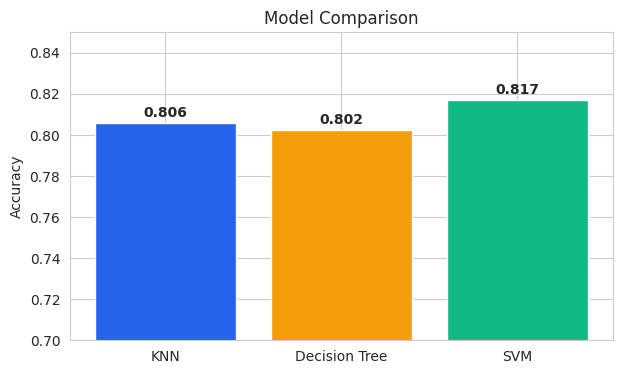

In [10]:
# visualize the comparison
plt.figure(figsize=(7, 4))
bars = plt.bar(results.keys(), results.values(), color=['#2563eb', '#f59e0b', '#10b981'])
plt.ylim(0.7, 0.85)
plt.ylabel('Accuracy')
plt.title('Model Comparison')
for bar, acc in zip(bars, results.values()):
    plt.text(bar.get_x() + bar.get_width()/2, acc + 0.003, f'{acc:.3f}', ha='center', fontweight='bold')
plt.show()

## 7. Evaluate the Best Model
SVM performed best, so let's look at its detailed results.

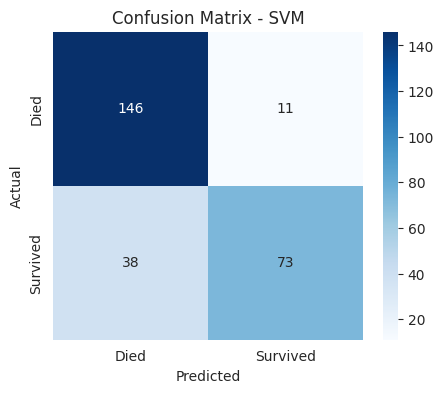

              precision    recall  f1-score   support

        Died       0.79      0.93      0.86       157
    Survived       0.87      0.66      0.75       111

    accuracy                           0.82       268
   macro avg       0.83      0.79      0.80       268
weighted avg       0.82      0.82      0.81       268



In [11]:
best_model = SVC(kernel='rbf', random_state=42)
best_model.fit(X_train_scaled, y_train)
y_pred = best_model.predict(X_test_scaled)

# confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Died', 'Survived'], yticklabels=['Died', 'Survived'])
plt.xlabel('Predicted'); plt.ylabel('Actual')
plt.title('Confusion Matrix - SVM')
plt.show()

print(classification_report(y_test, y_pred, target_names=['Died', 'Survived']))

## 8. Conclusion

**Results:**
- Best model: **SVM** with ~82% accuracy on the test set.
- All three models scored around 80% — solid for a real, messy dataset (random guessing would give ~62%).

**Key insights from the data:**
- **Sex** was the strongest predictor — females were far more likely to survive.
- **Passenger class** mattered a lot — 1st class survived at a much higher rate than 3rd.
- **Age** played a role — children had a relatively higher survival chance.

**Skills demonstrated in this project:**
- Data exploration & visualization (pandas, matplotlib, seaborn)
- Data cleaning: handling missing values, encoding categorical features, dropping noise
- Feature scaling & proper train/test splitting (avoiding data leakage)
- Training & comparing multiple ML models (KNN, Decision Tree, SVM)
- Model evaluation (accuracy, confusion matrix, classification report)

**Possible improvements:**
- Feature engineering (e.g. combine SibSp + Parch into 'family size')
- Hyperparameter tuning with GridSearchCV
- Try ensemble models (Random Forest, Gradient Boosting)